### $$\text{\LARGE \textbf{Apprentissage Fédéré sur le jeu de données MNIST}}$$
$$\text{\large \textcolor{blue}{\textbf{Benjamin SWIETEK - MASTER MIGS 2}}}$$

In [2]:
import io
import math
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import torch
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from torch.utils.data import Subset

### $\LARGE \textbf{Sommaire}$

### 1. Présentation du Dataset MNIST
### 2. Présentation de la régression logistique multinomial
### 3. Algorithme FedAvg
### 4. Influence des paramètres

### $\LARGE \textbf{Présentation du jeu de données MNIST}$

### Le jeu de données MNIST rassemble 70 000 images de chiffres manuscrits avec 60 000 pour l'entraînement et 10 000 pour les tests, normalisées et centrées dans des images 28×28 pixels. Sa structure est parfaite pour expérimenter l'apprentissage fédéré. La diversité des écritures manuscrites est illustrée dans la visualisation suivante :

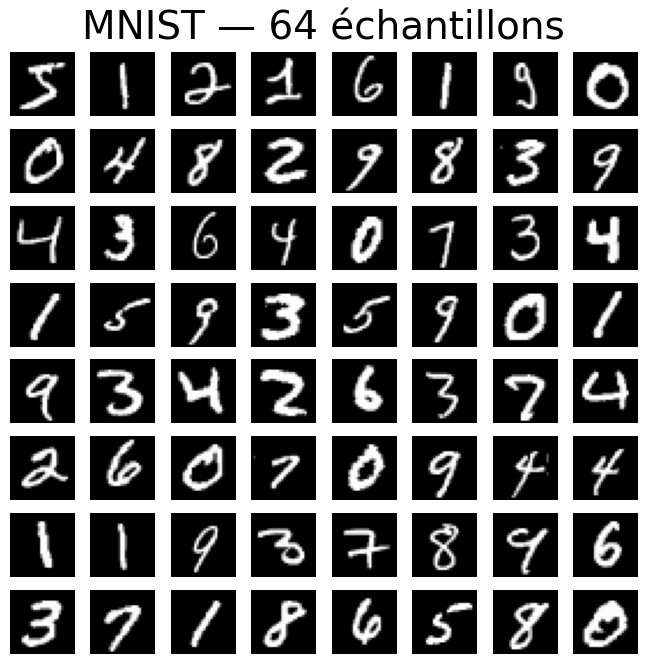

In [3]:
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

fig, ax = plt.subplots(nrows=8,ncols=8,figsize=(7,7)) 
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.06, top=0.92)  # centre + marges
fig.suptitle("MNIST — 64 échantillons", fontsize=28)         
c=-1
for l in range(64) :
    if ((l % 8) == 0) : 
        c=c+1
    img, label = mnist_train[l]
    ax[l%8,c].imshow(img[0],cmap="gray")
    ax[l%8,c].axis("off")
    ax[l%8,c].set_aspect("equal")



### $\LARGE \textbf{Présentation de la régression logistique multinomial}$

<div align="justify">

La régression logistique multinomial sera le modèle utilisé pour la classification des chiffres manuscrits MNIST.

</div>

---

#### $\large \textbf{Formalisation du problème}$

**Données d'apprentissage** :
$$
\{(x_i,y_i)\}_{i=1}^n,\quad x_i\in\mathbb{R}^d,\quad y_i\in\{1,\dots,K\}
$$

**Représentation one-hot** :
$$
Y \in \{0,1\}^{n\times K}
$$

**Paramètres du modèle** :
$$
W = [\beta_1, \dots, \beta_K] \in \mathbb{R}^{d\times K}, \quad b \in \mathbb{R}^K,\quad b\in\mathbb{R}^K \text{ (biais)}
$$

---

#### $\large \textbf{Architecture du modèle}$

**Calcul des logits** :
$$
z_{ij} = x_i^\top \beta_j + b_j
$$

**Fonction softmax** :
$$
p_{ij} = \frac{e^{z_{ij}}}{\sum_{k=1}^K e^{z_{ik}}}, \quad \sum_{j=1}^K p_{ij} = 1
$$

---

#### $\large \textbf{Fonction de coût et optimisation}$

**Log-vraisemblance** :
$$
\ell(W,b) = \sum_{i=1}^n\sum_{j=1}^K y_{ij}\,z_{ij} - \sum_{i=1}^n\log\!\Big(\sum_{k=1}^K e^{z_{ik}}\Big)
$$

**Gradients par classe** :
$$
\nabla_{\beta_j}\ell = \sum_{i=1}^n (y_{ij}-p_{ij})\,x_i, \quad
\frac{\partial \ell}{\partial b_j} = \sum_{i=1}^n (y_{ij}-p_{ij})
$$

---

#### $\large \textbf{Optimisations techniques}$

**Formulation standard** (sans absorption) :
$$
\nabla_W \ell = X^\top (Y - P),\quad \nabla_b \ell = \mathbf{1}^\top (Y - P)
$$

**Régularisation $L_2$** (uniquement sur $W$) :
$$
J(W,b) = -\ell(W,b) + \frac{\lambda}{2}\|W\|_F^2
$$

**Mise à jour des paramètres** :
$$
W \leftarrow W + \eta\left[X^\top (Y - P) - \lambda W\right],\quad
b \leftarrow b + \eta\,\mathbf{1}^\top (Y - P)
$$

---

In [4]:

ds = datasets.MNIST("./data",train=True,download=True,transform=transforms.ToTensor())

def initialisation(ind_client,clients):
    subset = clients[ind_client]
    n = len(subset)
    d = 28*28
    K = 10

    # Création des tableaux X et y
    X = np.stack([subset[i][0].view(-1).numpy() for i in range(n)])
    y = np.array([subset[i][1] for i in range(n)],dtype=np.int64)

    # One-hot encoding de y → Y
    Y = np.zeros((n,K), dtype=np.float32)
    Y[np.arange(n),y] = 1

    # Ajout de la colonne de biais (X_aug)
    ones = np.ones((n,1),dtype=np.float32)
    X_aug = np.hstack([X,ones])

    return X_aug,Y,n


def softmax(Z):
    Zs = Z-Z.max(axis=1,keepdims=True)
    return np.exp(Zs)/np.exp(Zs).sum(axis=1,keepdims=True)

def epoque_locale(X_aug,Y,epochs_local,lambda_l2,lr,W_global,batch_size=128):
    n = X_aug.shape[0]
    W = W_global.copy()
    reg_mask = np.ones_like(W); reg_mask[-1,:] = 0.0  # pas de L2 sur biais
    if batch_size is np.inf:          
        batch_size = X_aug.shape[0] 
    for _ in range(epochs_local):
        idx = np.random.permutation(n)
        Xs = X_aug[idx]  
        Ys = Y[idx]
        for start in range(0,n,batch_size):
            xb = Xs[start:start+batch_size]            
            yb = Ys[start:start+batch_size]            
            m  = xb.shape[0]
            Z  = xb@W                                
            P  = softmax(Z)                             
            grad = (xb.T@(yb-P))/m-lambda_l2*(W*reg_mask)
            W += lr*grad
    return W
 
def data_test():
    test_ds = datasets.MNIST("./data",train=False,download=True,transform=transforms.ToTensor())
    X_te_aug = (pd.DataFrame(np.vstack([test_ds[i][0].reshape(-1).numpy() for i in range(len(test_ds))]).astype('float32')).assign(bias=1.0).to_numpy(dtype='float32'))
    y_te = np.array([test_ds[i][1] for i in range(len(test_ds))], dtype=np.int64)                                                        
    return X_te_aug,y_te

def prop_pred(X_aug,y_true,W):
    Z = X_aug@W                
    P = softmax(Z)               
    y_pred = P.argmax(axis=1)    
    return float((y_pred==y_true).mean())


## $\large \textbf{Algorithme Federated Averaging}$

---

### $\textbf{Hyperparamètres}$

| Nom              | Description                                               |
|------------------|-----------------------------------------------------------|
| $R$              | Nombre de rounds de communication globaux                 |
| $E$              | Nombre d’époques locales effectuées par client            |
| $B$              | Taille de mini-batch local
| $\eta$            | Taux d’apprentissage local                                |
| $C$  | Fraction de clients sélectionnés à chaque round           |

---

### $\textbf{Protocole étape par étape}$

### 1. Initialisation (serveur)

$\hspace{10cm}$ $\blacktriangleright$ Le serveur initialise les poids globaux $w^{(0)}$.

$\hspace{10cm}$ $\blacktriangleright$ Il fixe les hyperparamètres : $(R, E, B, \nu, \mathrm{frac})$.

### 2. Sélection des clients (round $t = 0, \dots, R-1$)

$\hspace{10cm}$ $\blacktriangleright$ Le serveur échantillonne un sous-ensemble de clients $S_t \subset \{1, ..., K\}$ tel que  $|S_t| = \max\big(1, \lfloor C \cdot K \rfloor\big)$.

$\hspace{10cm}$ $\blacktriangleright$ Il diffuse $w^{(t)}$ à tous les clients $k \in S_t$.

### 3. Entraînement local (client $k$)

$\hspace{10cm}$ $\blacktriangleright$ Chaque client effectue $E$ époques de mini-batch à partir de $w^{(t)}$.

$\hspace{10cm}$ $\blacktriangleright$ Pour chaque mini-batch $\mathcal{B}$ de taille $m = \min(B, |\text{reste}|)$ : $$ g_k(w;\mathcal{B}) = \frac{1}{m} \sum_{(x,y)\in \mathcal{B}} \nabla_w \ell(w; x, y), \quad w \leftarrow w - \eta \cdot g_k(w;\mathcal{B}) $$

$\hspace{10cm}$ $\blacktriangleright$ Si $B = \infty$, alors $m = n_k$ càd une seule mise à jour par époque.

$\hspace{10cm}$ $\blacktriangleright$ À la fin, le client renvoie $w_k^{(t+1)}$ au serveur.

### 4. Agrégation (serveur)
$\hspace{10cm}$ $\blacktriangleright$ Le serveur effectue une moyenne pondérée des modèles locaux : $$ w^{(t+1)} = \sum_{k \in S_t} p_k \cdot w_k^{(t+1)},\qquad p_k = \frac{n_k}{\sum_{u \in S_t} n_u} $$

$\hspace{10cm}$ $\blacktriangleright$ Le modèle global $w^{(t+1)}$ est ensuite redistribué pour le round suivant.

---


In [5]:
def FedAvg(clients,n_rounds,epochs_local,lambda_l2=1e-4,lr=3e-3,batch_size=128,frac=0.3):
    rng = np.random.default_rng(123)
    d = 28*28
    K = 10
    acc_test = []
    X_test, y_test = data_test() 
   
    W_global = 0.01*rng.standard_normal((d+1,K)).astype(np.float32)  #Initialisation
    cached = [initialisation(j,clients) for j in range(len(clients))] 
    X_global = np.vstack([X_aug for (X_aug,Y,n_c) in cached])            
    y_global = np.argmax(np.vstack([Y for (X_aug,Y,n_c) in cached]),1) 

    for r in range(n_rounds):
        W_sum = np.zeros_like(W_global)
        total_n = 0
        m = max(1,int(frac*len(clients)))                          #Sélection des clients 
        sel = np.random.choice(len(clients),size=m,replace=False)  #
        for j in sel:
            X_aug,Y,n_c = cached[j]                                                        #
            W_local = epoque_locale(X_aug,Y,epochs_local,lambda_l2,lr,W_global,batch_size) #Entraînement local
            W_sum+=n_c*W_local                                                             #
            total_n+=n_c

        W_global = W_sum/float(total_n) #Agrégation
        acc = prop_pred(X_test,y_test,W_global)
        acc_test.append(acc)

    return W_global,acc_test


In [6]:
def nbr_rounds_lim(acc_curve,target=0.90):
    for r, v in enumerate(acc_curve):
        if v >= target:
            return r+1
    return None


def fct_u(E,B,n_bar):
    if B == np.inf:
        return int(E)
    return int(E*(n_bar/B))


def tab_graph(clients,configs,target=0.99,n_rounds=1000,lr=3e-3,lambda_l2=1e-4,frac=0.1):
    N = sum(len(cl.indices) for cl in clients)
    K = len(clients)
    n_bar = N/K
    res = []
    curves = []
    for cfg in configs:
        E,B = cfg['E'],cfg['B']
        Wg,acc_curve = FedAvg(clients,n_rounds=n_rounds,epochs_local=E,lambda_l2=lambda_l2,lr=lr,batch_size=B,frac=frac)
        rtt = nbr_rounds_lim(acc_curve,target=target)
        res.append(dict(E=E,B=B,u=fct_u(E,B,n_bar),rounds=rtt,last_acc=acc_curve[-1]))
        curves.append(acc_curve) 
        df =  pd.DataFrame(res)
    return df,curves


def data_iid(ds,n_clients=100,seed=0):
    y = ds.targets.numpy()
    skf = StratifiedKFold(n_splits=n_clients,shuffle=True,random_state=seed)
    clients = [Subset(ds,idx) for _,idx in skf.split(np.zeros_like(y),y)]
    return clients  


def data_noniid(ds,n_clients=100,shards_per_client=2,seed=0):
    y = ds.targets.numpy()
    order = np.argsort(y)

    n_shards = n_clients * shards_per_client
    shard_size = len(order) // n_shards

    shards = [order[i*shard_size:(i+1)*shard_size] for i in range(n_shards)]
    rng = np.random.default_rng(seed)
    rng.shuffle(shards)
    return [Subset(ds, np.concatenate(shards[c*shards_per_client:(c+1)*shards_per_client])) for c in range(n_clients)]



In [ ]:
#Paramètres
configs = [
    {'E':1,'B':np.inf},   
    {'E':5,'B':np.inf},
    {'E':1,'B':50},
    {'E':20,'B':np.inf},
    {'E':1,'B':10},
    {'E':5,'B':50},
    {'E':20,'B':50},
    {'E':5,'B':10},
    {'E':20,'B':10},
]

clients_iid = data_iid(ds,n_clients=100)
clients_noniid = data_noniid(ds,n_clients=100,shards_per_client=2,seed=0)

df_iid,curves_iid= tab_graph(clients_iid,configs,target=0.8,n_rounds=1000,lr=3e-3,lambda_l2=1e-4,frac=0.3)
df_noniid,curves_noniid = tab_graph(clients_noniid,configs,target=0.8,n_rounds=1000, lr=3e-3,lambda_l2=1e-4,frac=0.3)
tbl = (df_iid[['E','B','u','rounds']].rename(columns={'rounds':'IID'})).merge(df_noniid[['E','B','u','rounds']].rename(columns={'rounds':'NON-IID'}),on=['E','B','u'],how='inner')

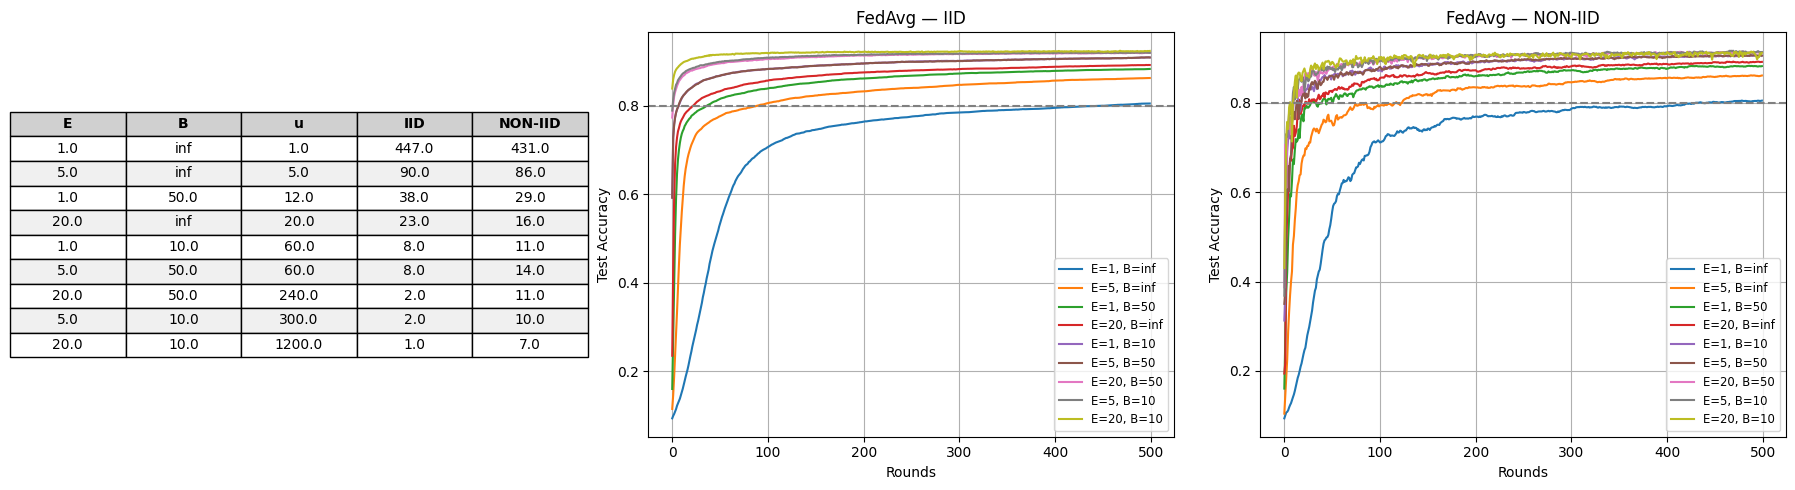

In [ ]:
def fct_tableau(title,df,ax):
    ax.axis('off')
    ax.set_title(title)
    table = ax.table(cellText=df.values,colLabels=df.columns,cellLoc='center',loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1,1.4)
    for (row,col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#d0d0d0')
        elif row > 0:
            cell.set_facecolor('#f0f0f0' if row % 2 == 0 else 'white')

def plot_curve(ax, curves, title):
    for acc, label in zip(curves, [f"E={c['E']}, B={c['B']}" for c in configs]):
        ax.plot(acc[:500], label=label)
    ax.axhline(0.8,color='gray',linestyle='--')
    ax.set_title(title)
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Test Accuracy")
    ax.grid(True)
    ax.legend(fontsize="small")

fig, axes = plt.subplots(1,3,figsize=(18,5))

fct_tableau("",tbl,axes[0])
plot_curve(axes[1], curves_iid,"FedAvg — IID")
plot_curve(axes[2], curves_noniid,"FedAvg — NON-IID")

plt.tight_layout()
plt.show()


L’objectif est d’évaluer le comportement de l’algorithme **FedAvg** en fonction de ses principaux hyperparamètres $\textbf{E}$ et $\textbf{B}$, et le nombre moyen d’itérations locales $\bm{u = \frac{E n}{K B}}$ dans des données **IID**  et **non-IID**. 

On fais varier $\textbf{E}$ et $\textbf{B}$ pour observer leur influence sur le nombre de tours de communication nécessaires pour atteindre une certaine accuracy.
Cette étude suit la méthodologie de McMahan et al. (2017).

L’objectif est d’analyser comment un compromis entre calcul local et communication global peut améliorer l’efficacité de l’apprentissage fédéré.

---
### Interprétation des résultats

**Influence de $\textbf{E}$** :  
  Lorsque le nombre d’époques locales $\textbf{E}$ augmente, le nombre de rounds nécessaires chute considérablement.  
  Chaque client effectue davantage d’apprentissage local avant la synchronisation, ce qui réduit la fréquence des échanges avec le serveur et donc le coût de communication.  

**Influence de $\textbf{B}$** :  
  Diminuer la taille de batch $\textbf{B}$ (donc augmenter $\textbf{u}$) améliore la vitesse de convergence.  
  Les clients effectuent plus de mises à jour locales par round, ce qui accélère l’apprentissage.

**Cas IID vs non-IID** :  
  En **IID** les clients ont des distributions similaires donc la convergence est stable et rapide.  
  En **non-IID**, la convergence est plus lente car les modèles locaux s’éloignent les uns des autres lorsque $\textbf{B}$ est grand.  
  
---

FedAvg fonctionne mieux quand on équilibre le calcul local et la fréquence de communication.  
Augmenter $\textbf{E}$ et réduire $\textbf{B}$ permet de gagner en efficacité.

In [ ]:
#paramètres
configs= [{'E':5,'B':np.inf}, {'E':5,'B': 10}]
C_list = [0.0,0.1,0.2,0.5,1]
clients_iid = data_iid(ds,n_clients=100)
clients_noniid = data_noniid(ds,n_clients=100,shards_per_client=2,seed=0)

def test_C(clients,C_list,configs):
    dfs = []
    curves = []
    for C in C_list:
        frac_eff = max(C,1/len(clients))
        df, curves = tab_graph(clients,configs,target=0.8,n_rounds=1200,lr=3e-3,lambda_l2=1e-4,frac=frac_eff)
        df["C"] = C
        dfs.append(df)
        for acc_curve in zip(curves):
            curves.append(acc_curve)
    return pd.concat(dfs,ignore_index=True),curves

df_iid, curves_iid = test_C(clients_iid,C_list,configs)
df_noniid, curves_noniid = test_C(clients_noniid,C_list,configs)


C:\Users\SWIETEK\AppData\Local\Temp\ipykernel_17772\1527699883.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tbl_10[col] = tbl_10[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")
C:\Users\SWIETEK\AppData\Local\Temp\ipykernel_17772\1527699883.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tbl_inf[col] = tbl_inf[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")


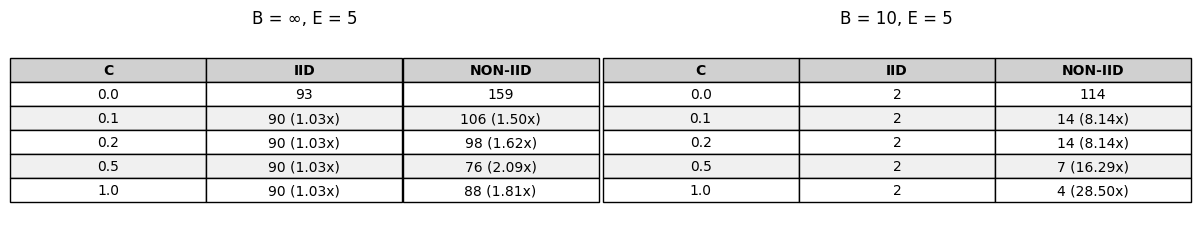

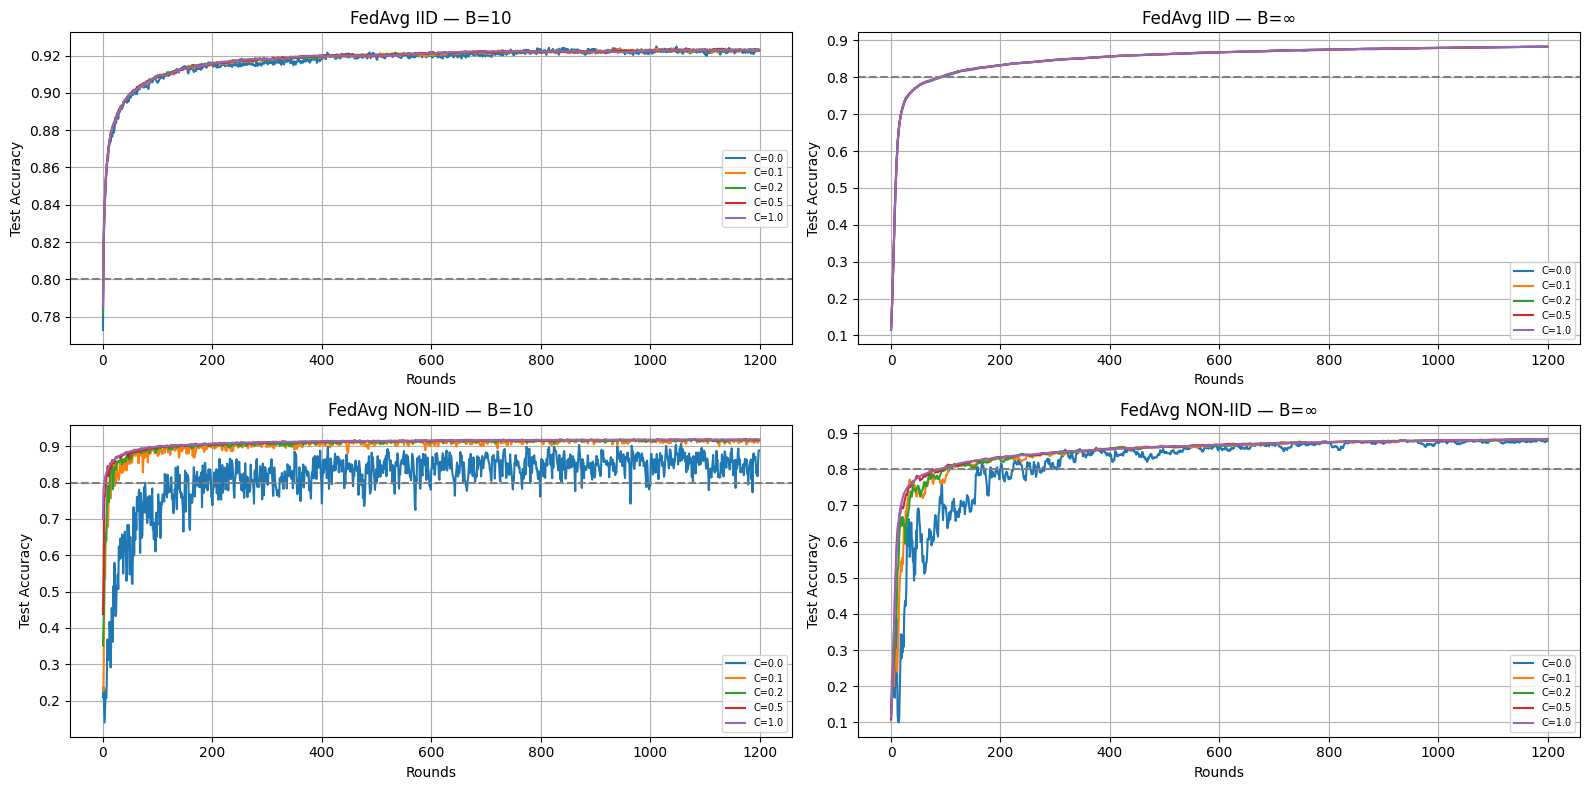

In [ ]:

def plot_curves(ax,curves,cfgs,B_target,title):
    for acc,cfg in zip(curves,cfgs.itertuples(index=False)):
        if cfg.B == B_target:
            label = f"C={cfg.C}"
            ax.plot(acc, label=label)
    ax.axhline(0.8,color='gray',linestyle='--')
    ax.set_title(f"{title}")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Test Accuracy")
    ax.grid(True)
    ax.legend(fontsize='x-small')


# Les tableaux
tbl = (df_iid[['E','B','C','rounds']].rename(columns={'rounds':'IID'})).merge(df_noniid[['E','B','C','rounds']].rename(columns={'rounds':'NON-IID'}),on=['E','B','C'],how='inner')
tbl['B'] = tbl['B'].apply(lambda b: '∞' if b == np.inf else str(int(b)))
tbl_10 = tbl[tbl['B'] == "10"]
tbl_inf = tbl[tbl['B'] == '∞']

for col in ['IID', 'NON-IID']:
    base = tbl_10[col].iloc[0]
    tbl_10[col] = tbl_10[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")
    base = tbl_inf[col].iloc[0]
    tbl_inf[col] = tbl_inf[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")

fig_tbl, ax_tbl = plt.subplots(1,2,figsize=(12,2.5))
fct_tableau(f"B = ∞, E = {tbl_inf['E'].iloc[0]}",tbl_inf[['C','IID','NON-IID']],ax_tbl[0])
fct_tableau(f"B = 10, E = {tbl_10['E'].iloc[0]}",tbl_10[['C','IID','NON-IID']],ax_tbl[1])
plt.tight_layout()
plt.show()




# Les graphes
params = [
    (curves_iid,df_iid,10,"FedAvg IID — B=10"),
    (curves_iid,df_iid,np.inf,"FedAvg IID — B=∞"),
    (curves_noniid,df_noniid,10,"FedAvg NON-IID — B=10"),
    (curves_noniid,df_noniid,np.inf,"FedAvg NON-IID — B=∞"),
]
fig, axes = plt.subplots(2,2,figsize=(16,8))
for ax, (curves,cfgs,B_val,title) in zip(axes.flat,params):
    plot_curves(ax,curves,cfgs,B_val,title)
plt.tight_layout()
plt.show()

Dans cette d’expérience, on garde fixes le nombre d’époques locales  $\textbf{E} = 5$ et deux tailles de batch :  $\textbf{B} = \infty$ et  $\textbf{B} = 10$ et on fait varier la fraction de clients $ \textbf{C} = \in \{0.0, 0.1, 0.2, 0.5, 1.0\}$.

L’objectif est de voir si impliquer plus de clients par round accélère réellement FedAvg, et si cet effet est le même en **IID** et en **non-IID**.

---

#### Cas $\textbf{B} = \infty, \textbf{E} = 5$

Pour les données **IID** le nombre de rounds est quasiment constant quel que soit $\textbf{C}$.

Pour les données **Non-IID** on voit un petit gain quand $\textbf{C}$ augmente mais le gain reste modéré.

Si les updates se font avec un gros batch, augmenter $\textbf{C}$ n’apporte pas grand-chose.


#### Cas $\textbf{B} = 10, \textbf{E} = 5$

Pour les données **IID** quelle que soit la valeur de $\textbf{C}$, on atteint la cible en 2 rounds. 

Pour les données **Non-IID** lorsque les updates locales se font avec un petit batch $\textbf{B}$, alors moyenner plus de clients dans le même round corrige le biais local.  

Donc avec des clients hétérogènes, la variance est entre les clients, donc la meilleure façon de la réduire, c’est de moyenner plus de clients.

En conclusion l’effet de $\textbf{C}$ apparaît surtout quand les données sont non-IID et que le batch est petit. 

---

Cela montre que la fraction de clients sélectionnés par round $\textbf{C}$ n’a qu’un impact limité lorsque les mises à jour locales ont un grand batch, mais devient un levier important dès que les données sont hétérogènes et que les clients utilisent de petits batch.

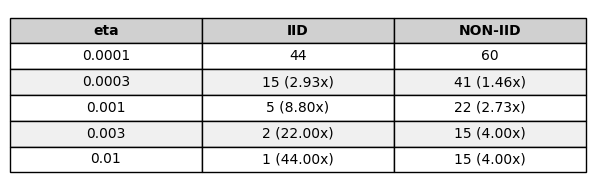

In [ ]:
#Paramètres
eta_list = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
config_eta_test = {'E': 5, 'B': 10}
C_eta = 0.1

def test_eta(clients,eta_list,config,C=0.1):
    all_dfs = []
    all_curves = []
    for eta in eta_list:
        df, curves = tab_graph(clients,[config],target=0.8,n_rounds=1200,lr=eta,lambda_l2=1e-4,frac=C)
        df["eta"] = eta
        all_dfs.append(df)
        all_curves.append(curves[0])
    return pd.concat(all_dfs,ignore_index=True),all_curves

df_eta_iid, curves_eta_iid = test_eta(clients_iid,eta_list,config_eta_test,C=C_eta)
df_eta_noniid, curves_eta_noniid = test_eta(clients_noniid,eta_list,config_eta_test,C=C_eta)
tbl_eta = df_eta_iid[['eta','rounds']].rename(columns={'rounds':'IID'}).merge(df_eta_noniid[['eta','rounds']].rename(columns={'rounds':'NON-IID'}), on='eta')

for col in ['IID','NON-IID']:
    base = tbl_eta[col].iloc[0]
    tbl_eta[col] = tbl_eta[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")

#Tableau
fig, ax = plt.subplots(figsize=(6, 2))
fct_tableau("",tbl_eta,ax)
plt.tight_layout()
plt.show()


Dans cette expérience, on évalue l’impact du taux d’apprentissage $\bm{\eta}$ sur la convergence de FedAvg.  
Les autres hyperparamètres sont fixés à $\textbf{E}$ = 5, $\textbf{B}$ = 10 et $\textbf{C}$ = 0.1.  
On teste plusieurs valeurs de $\bm{\eta} \in \{10^{-4}, 3\!\times\!10^{-4}, 10^{-3}, 3\!\times\!10^{-3}, 10^{-2}\}$.

---

### Interprétation des résultats

**Pour les données IID :**  
  La convergence s’accélère fortement lorsque $\bm{\eta}$ augmente, passant de 44 rounds à seulement 1 round.  
  Les mises à jour locales deviennent plus efficaces et la moyenne globale converge presque instantanément.

**Pour les données non‐IID :**  
  La tendance est similaire mais plus modérée la vitesse de convergence est environ multipliée par 4, puis se stabilise au-delà d’un certain seuil.  
  Les gradients locaux étant plus hétérogènes, une trop grande valeur de $\bm{\eta}$ peut amplifier les divergences entre clients.

---

En **IID**, augmenter $\bm{\eta}$ améliore nettement la vitesse de convergence jusqu’à un certain seuil.  
En **non‐IID** la stabilité devient le facteur limitant, un $\bm{\eta}$ trop grand n’apporte plus de gain et peut même dégrader la précision finale.  
Le choix du taux d’apprentissage doit donc trouver un équilibre entre rapidité et stabilité, en fonction du niveau d’hétérogénéité des données.

Matériel utilisé pour le calcul : cuda
Nom du GPU : NVIDIA GeForce RTX 5070 Ti
--- Lancement FedAvg (LR Fixe = 0.05) ---
Chargement des données clients sur GPU...
Début entraînement GPU : E=5, B=10
Round   0 | Loss: 2.2979 | Acc: 16.08%
Round  20 | Loss: 0.5429 | Acc: 83.34%
Round  40 | Loss: 0.6125 | Acc: 78.21%
Round  60 | Loss: 0.4577 | Acc: 86.08%
Round  80 | Loss: 0.5347 | Acc: 82.56%
Round 100 | Loss: 0.4852 | Acc: 84.12%
Round 120 | Loss: 0.5416 | Acc: 82.06%
Round 140 | Loss: 0.3752 | Acc: 89.37%
Round 160 | Loss: 0.3861 | Acc: 88.67%
Round 180 | Loss: 0.4649 | Acc: 84.43%
Round 200 | Loss: 0.4954 | Acc: 84.29%
Round 220 | Loss: 0.5164 | Acc: 82.25%
Round 240 | Loss: 0.3887 | Acc: 88.36%
Round 260 | Loss: 0.4266 | Acc: 86.81%
Round 280 | Loss: 0.4743 | Acc: 84.27%
Round 300 | Loss: 0.4389 | Acc: 86.28%
Round 320 | Loss: 0.3653 | Acc: 89.65%
Round 340 | Loss: 0.4082 | Acc: 87.30%
Round 360 | Loss: 0.4829 | Acc: 83.44%
Round 380 | Loss: 0.4978 | Acc: 82.49%
Round 400 | Loss: 0.48

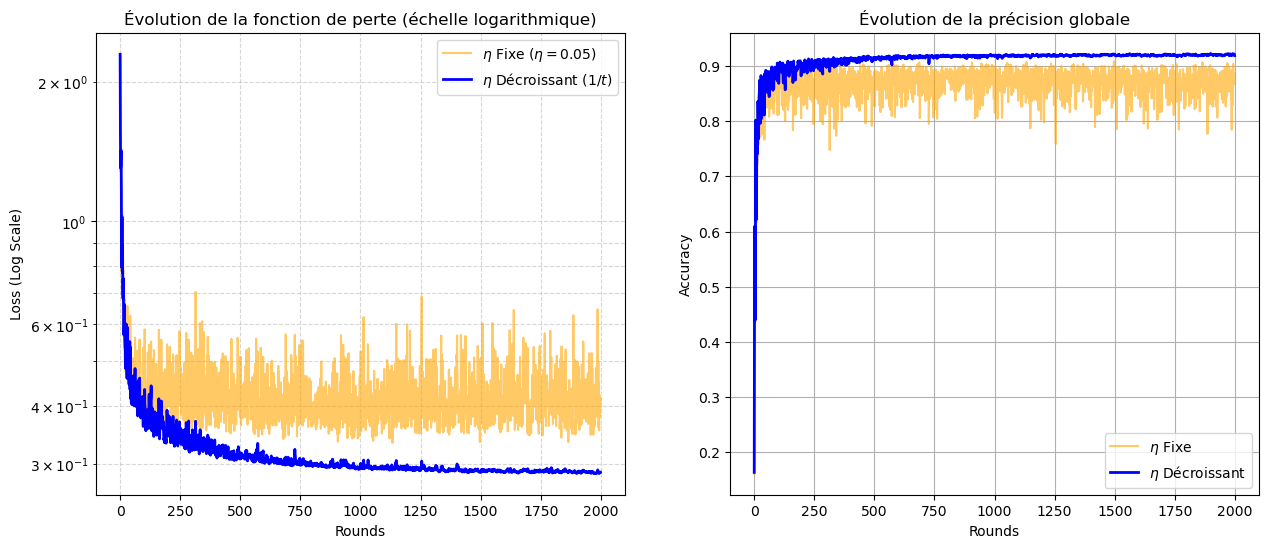

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import Subset

# --- 1. CONFIGURATION DU GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Matériel utilisé pour le calcul : {device}")
if device.type == 'cuda':
    print(f"Nom du GPU : {torch.cuda.get_device_name(0)}")

def prepare_data_gpu(dataset, device):
    data_loader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False) # Extraction des données
    images, labels = next(iter(data_loader)) 
    X = images.view(images.shape[0],-1).to(device) # Aplatir les images (N, 784) 
    n = X.shape[0]
    ones = torch.ones((n,1),device=device) # Ajout du biais (colonne de 1)
    X_aug = torch.cat([X,ones],dim=1)
    y = labels.to(device) # Labels 
    K = 10 # One-Hot Encoding 
    Y_oh = torch.zeros((n,K),device=device)
    Y_oh.scatter_(1,y.view(-1,1),1)
    return X_aug, y, Y_oh


def softmax_gpu(Z):
    return torch.softmax(Z,dim=1)

def calculate_loss_gpu(X_aug,Y_oh,W,lambda_l2=0):
    n = X_aug.shape[0]
    Z = X_aug @ W
    P = softmax_gpu(Z)
    epsilon = 1e-9
    ce_loss = -torch.sum(Y_oh*torch.log(P+epsilon))/n
    if lambda_l2 > 0:
        ce_loss += (lambda_l2/2)*torch.sum(W**2)
    return ce_loss.item() 

def prop_pred_gpu(X_aug, y_true,W):
    Z = X_aug @ W
    y_pred = torch.argmax(Z,dim=1)
    correct = (y_pred==y_true).sum().item()
    return correct/y_true.shape[0]

def epoque_locale_gpu(X_aug,Y,epochs,lambda_l2,lr,W_init,batch_size):
    n = X_aug.shape[0]
    W = W_init.clone()
    for _ in range(epochs):
        indices = torch.randperm(n,device=device)
        X_shuf = X_aug[indices]
        Y_shuf = Y[indices]
        for start in range(0,n,batch_size):
            end = min(start+batch_size,n)
            xb = X_shuf[start:end]
            yb = Y_shuf[start:end]
            m = xb.shape[0]
            Z = xb@W
            P = softmax_gpu(Z)
            grad = (xb.T@(P-yb))/m+lambda_l2*W
            W -= lr*grad
    return W

def initialisation_client_gpu(subset,device):
    indices = subset.indices
    dataset_full = subset.dataset
    X_all = dataset_full.data.float() / 255.0 # Normalisation
    y_all = dataset_full.targets
    X_client = X_all[indices].view(len(indices), -1).to(device)
    y_client = y_all[indices].to(device)
    n = X_client.shape[0]
    K = 10
    ones = torch.ones((n,1),device=device) # Ajout Biais
    X_aug = torch.cat([X_client,ones],dim=1)
    Y_oh = torch.zeros((n,K),device=device) # One Hot
    Y_oh.scatter_(1,y_client.view(-1,1),1)
    return X_aug,Y_oh, n

def data_noniid(ds,n_clients=100,shards_per_client=2,seed=0):
    y = ds.targets.numpy()
    order = np.argsort(y)
    n_shards = n_clients*shards_per_client
    shard_size = len(order) // n_shards
    shards = [order[i*shard_size : (i+1)*shard_size] for i in range(n_shards)]
    rng = np.random.default_rng(seed)
    rng.shuffle(shards)
    clients = []
    for c in range(n_clients):
        client_indices = np.concatenate(shards[c*shards_per_client : (c+1)*shards_per_client])
        clients.append(Subset(ds,client_indices))
    return clients


# --- ALGORITHME FEDAVG GPU ---

def FedAvg_GPU(clients,n_rounds,epochs_local,batch_size,lambda_l2=1e-4,lr_0=0.1,decay=True,frac=0.1):
    d = 28*28
    K = 10
    W_global = (0.01*torch.randn((d+1,K),device=device))
    cached_clients = [initialisation_client_gpu(c,device) for c in clients]
    history_loss = []
    history_acc = []
    rng = np.random.default_rng(42)
    for r in range(n_rounds):
        current_lr = lr_0/(1+0.05*r) if decay else lr_0
        m = max(1, int(frac * len(clients))) # Sélection clients
        idxs_selected = rng.choice(len(clients), size=m, replace=False)
        W_sum = torch.zeros_like(W_global)
        total_samples = 0
        for idx in idxs_selected:
            X_c, Y_c, n_c = cached_clients[idx]
            W_new = epoque_locale_gpu(X_c,Y_c,epochs_local,lambda_l2,current_lr,W_global,batch_size) # Entraînement local 
            W_sum += W_new * n_c
            total_samples += n_c
        W_global = W_sum/total_samples # Agrégation 
        loss = calculate_loss_gpu(X_test_gpu, Y_test_oh_gpu, W_global, lambda_l2)
        acc = prop_pred_gpu(X_test_gpu, y_test_gpu, W_global)
        history_loss.append(loss)
        history_acc.append(acc)
        if r % 20 == 0:
            print(f"Round {r:3d} | Loss: {loss:.4f} | Acc: {acc:.2%}")
    return history_loss,history_acc

# --- LANCEMENT ---

ds_train = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
ds_test = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
X_test_gpu,y_test_gpu,Y_test_oh_gpu = prepare_data_gpu(ds_test,device) # Préparation du TestSet
clients_noniid = data_noniid(ds_train,n_clients=100,shards_per_client=2)

# Paramètres
ROUNDS = 2000        
EPOCHS = 5          
BATCH = 10         
FRAC = 0.1

loss_fixe, acc_fixe = FedAvg_GPU(clients_noniid,n_rounds=ROUNDS,epochs_local=EPOCHS,batch_size=BATCH,lr_0=0.05,decay=False,frac=FRAC)
loss_decay, acc_decay = FedAvg_GPU(clients_noniid,n_rounds=ROUNDS,epochs_local=EPOCHS,batch_size=BATCH, lr_0=0.05,decay=True,frac=FRAC)

# AFFICHAGE 
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,6))

# Loss en Log-Log (Le juge de paix pour la théorie)
ax1.plot(loss_fixe, label='$\eta$ Fixe ($\eta=0.05$)', color='orange', alpha=0.6)
ax1.plot(loss_decay, label='$\eta$ Décroissant ($1/t$)', color='blue', linewidth=2)
ax1.set_yscale('log') 
ax1.set_title("Évolution de la fonction de perte (échelle logarithmique)")
ax1.set_xlabel("Rounds")
ax1.set_ylabel("Loss (Log Scale)")
ax1.grid(True, which="both", linestyle='--', alpha=0.5)
ax1.legend()

# Accuracy (Ce qui intéresse le client)
ax2.plot(acc_fixe, label='$\eta$ Fixe', color='orange', alpha=0.6)
ax2.plot(acc_decay, label='$\eta$ Décroissant', color='blue', linewidth=2)
ax2.set_title("Évolution de la précision globale")
ax2.set_xlabel("Rounds")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
ax2.legend()

plt.show()

Entraînement préliminaire pour obtenir un 'vrai W'...
Précision du modèle après entraînement : 88.83%
--- Démarrage de l'attaque par inversion de gradient ---
Victime : Client 0, Image index 0
Classe réelle de l'image : 5


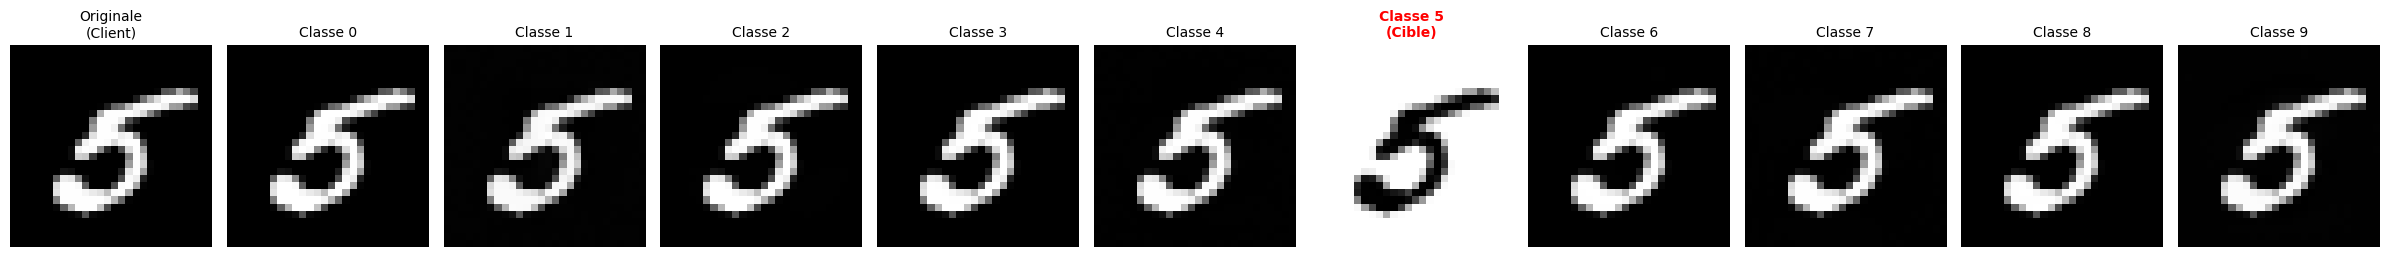

In [ ]:

def demo_attaque_inversion_gradient(clients,W_global,lambda_l2=1e-4,lr=0.01):
    ind_client_victime = 0
    X_aug,Y,n = initialisation(ind_client_victime,clients) # Sélection d'une victime et d'une image unique
    idx_image = 0
    X_victime = X_aug[idx_image:idx_image+1] # Shape (1,785)
    Y_victime = Y[idx_image:idx_image+1] # Shape (1,10)
    label_reelle = np.argmax(Y_victime) # Récupération du label réel pour vérification
    print(f"Victime : Client {ind_client_victime}, Image index {idx_image}")
    print(f"Classe réelle de l'image : {label_reelle}")
    W_new = epoque_locale(X_victime,Y_victime,epochs_local=1,lambda_l2=lambda_l2,lr=lr,W_global=W_global,batch_size=1) # Exécution d'une époque locale sur cette image unique
    gradient_reconstruit = (W_global-W_new)/lr # L'attaque côté serveur
    plt.figure(figsize=(24,3)) # Visualisation
    plt.subplot(1,11,1) 
    plt.title("Originale\n(Client)", fontsize=10)
    plt.imshow(X_victime[0,:-1].reshape(28,28),cmap='gray')
    plt.axis('off')

    # Les Gradients 
    for k in range(10):
        plt.subplot(1,11,k+2) 
        grad_col = gradient_reconstruit[:-1, k]
        img_reconstruite = grad_col.reshape(28, 28)
        plt.imshow(img_reconstruite, cmap='grey') 
        titre = f"Classe {k}"
        if k == label_reelle:
            plt.title(titre + "\n(Cible)", color='red', fontweight='bold', fontsize=10)
            ax = plt.gca()
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)
        else:
            plt.title(titre, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Données 
ds = datasets.MNIST("./data",train=True,download=True,transform=transforms.ToTensor())
clients = data_noniid(ds,n_clients=100) 
# On entraîne le modèle pendant quelques rounds pour obtenir un W réaliste
W_entraine, acc_curve = FedAvg(clients,n_rounds=100,epochs_local=10, lr=0.01)
demo_attaque_inversion_gradient(clients, W_entraine)

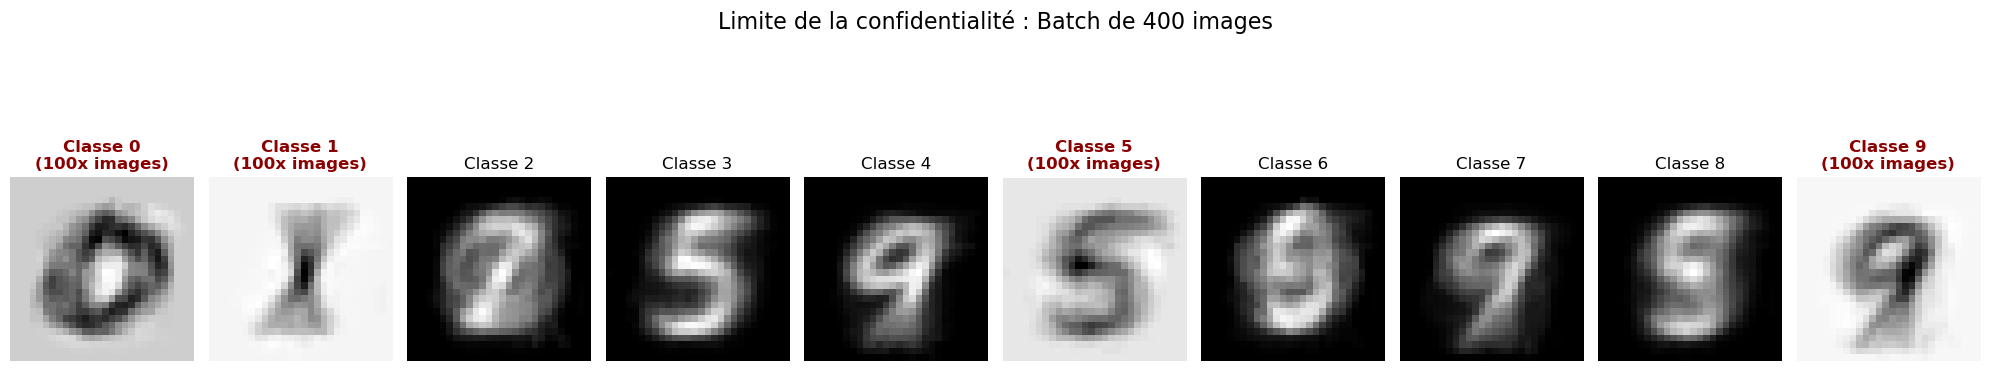

In [ ]:

def demo_superposition_limite(clients,W_global,lr=0.01):
    classes_cibles = [0, 1, 5, 9]
    n_images_par_classe = 100 # Passage à 100 images
    dict_images = {c: [] for c in classes_cibles}
    
    for id_c in range(len(clients)):
        X_aug, Y, _ = initialisation(id_c,clients)
        labels = np.argmax(Y,axis=1)
        for c in classes_cibles:
            if len(dict_images[c])<n_images_par_classe:
                idx = np.where(labels==c)[0]
                for i in idx:
                    if len(dict_images[c])<n_images_par_classe:
                        dict_images[c].append(X_aug[i])
        if all(len(dict_images[c]) == n_images_par_classe for c in classes_cibles):
            break

    X_batch = np.array(dict_images[0] + dict_images[1] + dict_images[5] + dict_images[9])
    Y_batch = np.zeros((400,10))
    Y_batch[0:100,0] = 1
    Y_batch[100:200,1] = 1
    Y_batch[200:300,5] = 1
    Y_batch[300:400,9] = 1
    n_k = 400
    # Calcul du gradient moyen
    W_new = epoque_locale(X_batch, Y_batch,epochs_local=1,lambda_l2=1e-4,lr=lr,W_global=W_global, batch_size=int(400))
    gradient_intercepte = (W_global-W_new)/lr
    # Visualisation
    plt.figure(figsize=(20,5))
    for k in range(10):
        plt.subplot(1,10,k+1)
        grad_col = gradient_intercepte[:-1,k]
        img_reconstruite = grad_col.reshape(28, 28)
        plt.imshow(img_reconstruite, cmap='gray')
        if k in classes_cibles:
            plt.title(f"Classe {k}\n(100x images)", color='darkred',fontweight='bold')
        else:
            plt.title(f"Classe {k}")
        plt.axis('off')
    plt.suptitle(f"Limite de la confidentialité : Batch de {n_k} images",fontsize=16)
    plt.tight_layout()
    plt.show()

demo_superposition_limite(clients, W_entraine)

Calcul en cours...
 > Batch Size: 1
 > Batch Size: 2
 > Batch Size: 4
 > Batch Size: 8
 > Batch Size: 16
 > Batch Size: 32
 > Batch Size: 64
 > Batch Size: 128


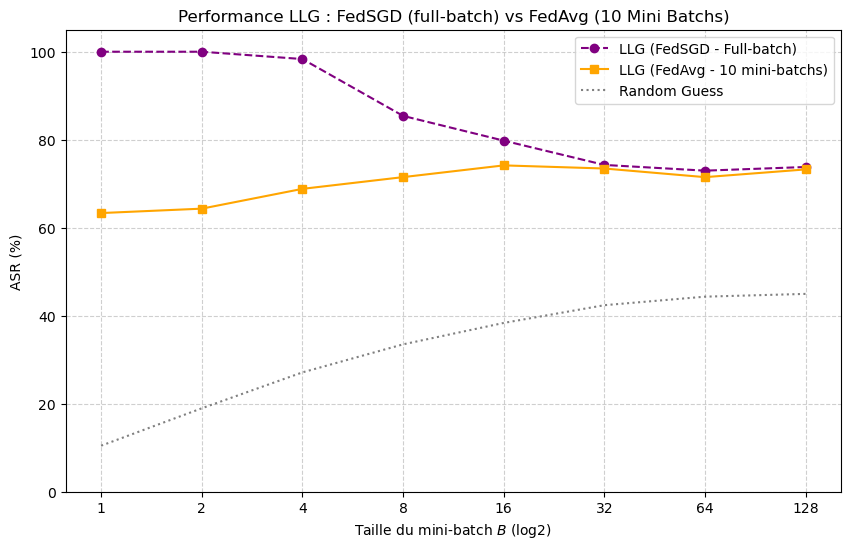

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
from torchvision import datasets, transforms





def get_unbalanced_data(ds,total_size,n_classes=10):
    """ Génère un batch déséquilibré (50% A, 25% B, 25% Reste) """
    class_a = np.random.randint(0,n_classes)
    class_b = np.random.randint(0,n_classes)
    while class_b == class_a:class_b=np.random.randint(0,n_classes)
    n_a = int(0.5*total_size)
    n_b = int(0.25*total_size)
    n_rest = total_size-n_a-n_b
    targets = ds.targets.numpy()
    idx_a = np.where(targets==class_a)[0]
    idx_b = np.where(targets==class_b)[0]
    idx_rest = np.where((targets!=class_a) & (targets!=class_b))[0]
    # Random choice safe
    indices = np.concatenate([
        np.random.choice(idx_a,n_a,replace=(n_a>len(idx_a))),
        np.random.choice(idx_b,n_b,replace=(n_b>len(idx_b))),
        np.random.choice(idx_rest,n_rest,replace=(n_rest>len(idx_rest)))
    ])
    # Extraction et formatage
    X_list,y_list = [],[]
    for i in indices:
        img, lbl = ds[i]
        X_list.append(img.view(-1).numpy())
        y_list.append(lbl)
    X = np.stack(X_list)
    y_vals = np.array(y_list,dtype=np.int64)
    Y = np.zeros((total_size,n_classes),dtype=np.float32) # One-hot
    Y[np.arange(total_size),y_vals] = 1
    X_aug = np.hstack([X,np.ones((total_size,1),dtype=np.float32)]) # Biais
    return X_aug, Y, y_vals

# ATTAQUE 

def llg_attack_algo1(gradient_matrix,batch_size,n_classes=10):
    G = np.sum(gradient_matrix,axis=0) 
    G_work = G.copy()
    extracted_labels = []
    # Estimation Impact m
    neg_grads = G_work[G_work<0]
    if len(neg_grads)>0:
        m = (np.sum(neg_grads)/batch_size)*(1+1/n_classes) # Formule empirique de l'article
    else:
        m = -1.0 # Fallback
    # Phase 1 : Signe (Propriété 1)
    initial_negatives = np.where(G_work<0)[0]
    for c in initial_negatives:
        extracted_labels.append(c)
        G_work[c]-=m # On retire l'impact (ce qui augmente la valeur vers 0)
    # Phase 2 : Magnitude (Propriété 2)
    while len(extracted_labels)<batch_size:
        c_min = np.argmin(G_work)
        extracted_labels.append(c_min)
        G_work[c_min] -= m
    return extracted_labels



def random_guess_asr(true_labels,n_classes=10,n_sim=1000):
    B = len(true_labels)
    true_counts = Counter(true_labels)
    scores = []
    for _ in range(n_sim):
        preds = np.random.randint(0, n_classes, size=B)
        pred_counts = Counter(preds)
        correct = sum(min(true_counts[k], pred_counts.get(k, 0)) for k in true_counts)
        scores.append(correct / B * 100)
    return np.mean(scores)


def run_comparison_graph():
    # Chargement des données
    ds = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
    batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
    n_repeats = 30 # Suffisant pour lisser
    lr = 0.1
    d = 28*28
    K = 10
    asr_fedsgd = []
    asr_fedavg = []
    for B in batch_sizes:
        print(f" > Batch Size: {B}")
        scores_sgd = []
        scores_avg = []
        for _ in range(n_repeats):
            # Modèle aléatoire non entrainé
            W_init = 0.01*np.random.randn(d+1,K).astype(np.float32)
            # FedSGD full Batch
            X, Y, true_labels = get_unbalanced_data(ds,total_size=B)
            W_new = epoque_locale(X,Y,1,0,lr,W_init,batch_size=B)
            grad_attack_sgd = (W_init-W_new)/lr
            extracted = llg_attack_algo1(grad_attack_sgd,B)
            # Calcul Accuracy ASR
            c_true = Counter(true_labels)
            c_pred = Counter(extracted)
            correct = sum(min(c_true[k],c_pred[k]) for k in c_true)
            scores_sgd.append(correct/B*100)
            # FedAvg 10 Batches
            total_size_avg = 10 * B
            X_avg, Y_avg, true_labels_avg = get_unbalanced_data(ds, total_size=total_size_avg)
            # On lance 10 itérations (car batch_size=B et dataset=10*B)
            W_new_avg = epoque_locale(X_avg,Y_avg,1,0,lr,W_init,batch_size=B)
            grad_attack_avg = (W_init-W_new_avg)/lr
            extracted_avg = llg_attack_algo1(grad_attack_avg, total_size_avg)
            c_true_avg = Counter(true_labels_avg)
            c_pred_avg = Counter(extracted_avg)
            correct_avg = sum(min(c_true_avg[k], c_pred_avg[k]) for k in c_true_avg)
            scores_avg.append(correct_avg / total_size_avg * 100)
        asr_fedsgd.append(np.mean(scores_sgd))
        asr_fedavg.append(np.mean(scores_avg))

    # Dans run_comparison_graph, avant la boucle sur B, initialiser une liste
    baseline_per_B = []
    batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
    for B in batch_sizes:
        # Calcul de la baseline pour cette taille
        bs_scores = []
        for _ in range(50):  # nombre de batches pour estimer la baseline
            _, _, true_lbl = get_unbalanced_data(ds, total_size=B)
            bs_scores.append(random_guess_asr(true_lbl, n_classes=10, n_sim=200))
        baseline_per_B.append(np.mean(bs_scores))

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(batch_sizes, asr_fedsgd, 'o--', color='purple', label='LLG (FedSGD - Full-batch)')
    plt.plot(batch_sizes, asr_fedavg, 's-', color='orange', label='LLG (FedAvg - 10 mini-batchs)')
    plt.plot(batch_sizes, baseline_per_B, ':', color='gray', label='Random Guess')
    
    plt.xscale('log', base=2)
    plt.xticks(batch_sizes, labels=batch_sizes)
    plt.xlabel("Taille du mini-batch $B$ (log2)")
    plt.ylabel("ASR (%)")
    plt.title("Performance LLG : FedSGD (full-batch) vs FedAvg (10 Mini Batchs)")
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.savefig("llg_result_fixed.png")
    plt.show()






run_comparison_graph()

Calcul de la baseline random guess...
Baseline random guess = 44.7%
Distribution Non-IID des données aux clients...

--- Simulation : FedSGD (Full Batch) ---
Round   0 | Acc: 9.5% | ASR: 74.4%
Round  10 | Acc: 78.2% | ASR: 74.1%
Round  20 | Acc: 82.1% | ASR: 74.2%
Round  30 | Acc: 83.8% | ASR: 75.1%
Round  40 | Acc: 84.6% | ASR: 75.2%
Round  50 | Acc: 85.5% | ASR: 75.5%
Round  60 | Acc: 85.8% | ASR: 74.8%
Round  70 | Acc: 86.4% | ASR: 74.7%
Round  80 | Acc: 86.9% | ASR: 76.2%
Round  90 | Acc: 86.9% | ASR: 71.4%
Round 100 | Acc: 87.3% | ASR: 73.7%
Round 110 | Acc: 87.5% | ASR: 74.8%
Round 120 | Acc: 87.8% | ASR: 74.1%
Round 130 | Acc: 87.7% | ASR: 72.2%
Round 140 | Acc: 88.0% | ASR: 74.0%
Round 150 | Acc: 88.0% | ASR: 70.7%
Round 160 | Acc: 88.3% | ASR: 72.9%
Round 170 | Acc: 88.1% | ASR: 74.1%
Round 180 | Acc: 88.2% | ASR: 74.3%
Round 190 | Acc: 88.5% | ASR: 73.5%
Round 200 | Acc: 88.6% | ASR: 67.6%

--- Simulation : FedAvg (B=10) ---
Round   0 | Acc: 9.4% | ASR: 75.9%
Round  10 | Acc:

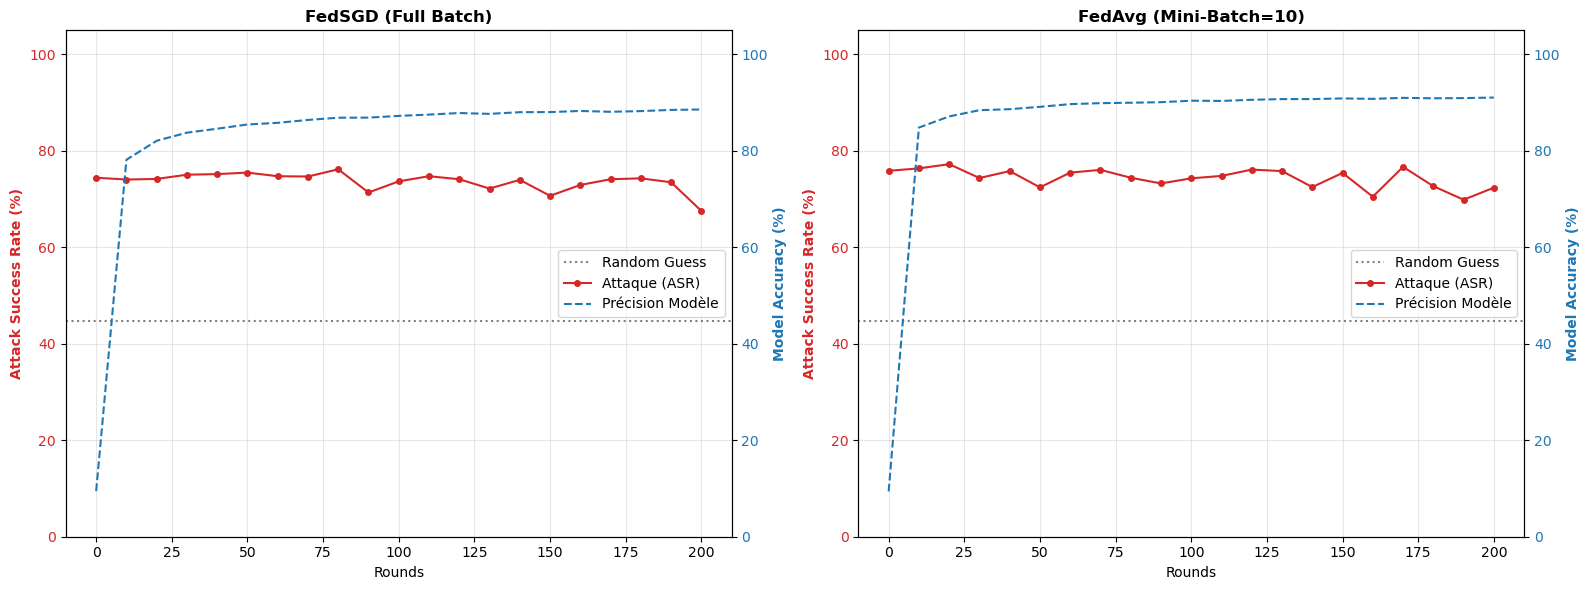

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import torch
from torchvision import datasets,transforms


def get_client_data_unbalanced(ds,indices):
    X_list,y_list=[],[]
    for i in indices:
        img, lbl = ds[i]
        X_list.append(img.view(-1).numpy())
        y_list.append(lbl)
    total_size = len(indices)
    X = np.stack(X_list)
    y_vals = np.array(y_list,dtype=np.int64)
    Y = np.zeros((total_size,10),dtype=np.float32)
    Y[np.arange(total_size),y_vals] = 1
    X_aug = np.hstack([X,np.ones((total_size,1),dtype=np.float32)])
    return X_aug,Y,y_vals


def setup_clients_unbalanced(ds, n_clients=750):
    client_indices = []
    all_targets = ds.targets.numpy()
    indices_by_label = [np.where(all_targets == i)[0] for i in range(10)]
    for i in range(n_clients):
        c_a,c_b=np.random.choice(10,2,replace=False)
        n_a,n_b,n_rest=40,20,20 
        idx_a = np.random.choice(indices_by_label[c_a],n_a)
        idx_b = np.random.choice(indices_by_label[c_b],n_b)
        candidates_rest = []
        for l in range(10):
            if l!=c_a and l!=c_b:
                candidates_rest.extend(indices_by_label[l])
        idx_rest = np.random.choice(candidates_rest,n_rest)
        client_indices.append(np.concatenate([idx_a,idx_b,idx_rest]))
    return client_indices


def run_simulation(mode,clients_indices,n_rounds=200):
    n_clients=len(clients_indices)
    clients_per_round=50
    lr=0.1
    samples_per_client=80
    if mode == 'fedsgd':
        train_batch_size = samples_per_client # Full batch
        label_plot = "FedSGD (Full Batch)"
    else:
        train_batch_size = 10 # Mini-batch typique FedAvg
        label_plot = f"FedAvg (B={train_batch_size})"
    d = 28*28
    K = 10
    W_global = 0.01*np.random.randn(d+1,K).astype(np.float32)
    history_rounds = []
    history_acc = []
    history_asr = []
    print(f"\n--- Simulation : {label_plot} ---")
    for r in range(n_rounds + 1):
        # Entraînement
        selected_clients = np.random.choice(n_clients,clients_per_round,replace=False)
        W_sum = np.zeros_like(W_global)
        for client_id in selected_clients:
            X_c,Y_c,_ = get_client_data_unbalanced(ds,clients_indices[client_id])
            W_local = epoque_locale(X_c,Y_c,epochs_local=1,lambda_l2=0,lr=lr,W_global=W_global,batch_size=train_batch_size)
            W_sum += W_local
        W_new_global = W_sum/clients_per_round
        
        # Évaluation tous les 10 rounds 
        if r % 10 == 0:
            Z_test = X_test_aug@W_global
            pred_test = np.argmax(Z_test,axis=1)
            acc = np.mean(pred_test==y_test_all)*100
            scores = [] 
            for _ in range(20): # Attaque (sur 20 victimes)
                vid = np.random.randint(n_clients)
                X_v,Y_v,true_labels_v = get_client_data_unbalanced(ds,clients_indices[vid])
                W_vic = epoque_locale(X_v,Y_v,epochs_local=1,lambda_l2=0,lr=lr,W_global=W_global,batch_size=train_batch_size)
                grad_received = (W_global-W_vic)/lr
                extracted = llg_attack_algo1(grad_received, batch_size=samples_per_client) # Attaque
                c_true = Counter(true_labels_v)
                c_pred = Counter(extracted)
                correct = sum(min(c_true[k],c_pred[k]) for k in c_true)
                scores.append(correct/samples_per_client*100)
            mean_asr = np.mean(scores)
            history_rounds.append(r)
            history_acc.append(acc)
            history_asr.append(mean_asr)
            print(f"Round {r:3d} | Acc: {acc:.1f}% | ASR: {mean_asr:.1f}%")
        W_global = W_new_global
    return history_rounds, history_acc, history_asr, label_plot


def get_unbalanced_data_for_baseline(ds,total_size=80):
    """Génère un batch déséquilibré (50% A, 25% B, 25% reste) pour la baseline."""
    class_a=np.random.randint(0,10)
    class_b=np.random.randint(0,10)
    while class_b==class_a:
        class_b=np.random.randint(0,10)
    n_a = int(0.5*total_size)
    n_b = int(0.25*total_size)
    n_rest = total_size-n_a-n_b
    targets = ds.targets.numpy()
    idx_a = np.where(targets==class_a)[0]
    idx_b = np.where(targets==class_b)[0]
    idx_rest = np.where((targets!=class_a) & (targets!=class_b))[0]
    indices = np.concatenate([
        np.random.choice(idx_a,n_a,replace=(n_a>len(idx_a))),
        np.random.choice(idx_b,n_b,replace=(n_b>len(idx_b))),
        np.random.choice(idx_rest,n_rest,replace=(n_rest>len(idx_rest)))
    ])
    _, _, y_vals = get_client_data_unbalanced(ds,indices)
    return y_vals


def plot_dual_axis(ax_main, res, title, baseline):
    rounds, acc, asr, label = res
    
    ax_main.set_title(title, fontsize=12, fontweight='bold')
    ax_main.set_xlabel('Rounds')
    ax_main.grid(True, alpha=0.3)
    
    # AXE GAUCHE (ASR - Rouge)
    ax_main.set_ylabel('Attack Success Rate (%)', color='tab:red', fontweight='bold')
    l1, = ax_main.plot(rounds, asr, color='tab:red', marker='o', markersize=4, label='Attaque (ASR)')
    ax_main.tick_params(axis='y', labelcolor='tab:red')
    ax_main.set_ylim(0, 105)
    
    # Baseline
    l0 = ax_main.axhline(y=baseline, color='gray', linestyle=':', label='Random Guess')
    
    # AXE DROITE (Accuracy - Bleu)
    ax_secondary = ax_main.twinx()
    ax_secondary.set_ylabel('Model Accuracy (%)', color='tab:blue', fontweight='bold')
    l2, = ax_secondary.plot(rounds, acc, color='tab:blue', linestyle='--', label='Précision Modèle')
    ax_secondary.tick_params(axis='y', labelcolor='tab:blue')
    ax_secondary.set_ylim(0, 105)
    
    # Légende combinée
    lines = [l0, l1, l2]
    labels = [l.get_label() for l in lines]
    ax_main.legend(lines, labels, loc='center right')





# CONFIGURATION & DATA 

ds = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test_ds = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())

# Préparation
X_test_all = np.stack([test_ds[i][0].view(-1).numpy() for i in range(len(test_ds))])
X_test_aug = np.hstack([X_test_all, np.ones((len(test_ds), 1))])
y_test_all = np.array([test_ds[i][1] for i in range(len(test_ds))])
baseline_scores = []
for _ in range(500):
    true_lbl = get_unbalanced_data_for_baseline(ds,total_size=80)
    baseline_scores.append(random_guess_asr(true_lbl,n_classes=10,n_sim=200))
baseline_value = np.mean(baseline_scores)

# EXÉCUTION

indices_clients = setup_clients_unbalanced(ds)
res_sgd = run_simulation('fedsgd', indices_clients, n_rounds=200)
res_avg = run_simulation('fedavg', indices_clients, n_rounds=200)
fig, (ax1_left, ax2_left) = plt.subplots(1, 2, figsize=(16, 6))
plot_dual_axis(ax1_left, res_sgd, "FedSGD (Full Batch)", baseline_value)
plot_dual_axis(ax2_left, res_avg, "FedAvg (Mini-Batch=10)", baseline_value)
plt.tight_layout()
plt.savefig("fedavg_fedsgd_dual_axis.png")
plt.show()